<div style="position: relative; background: linear-gradient(135deg, #24398A 0%, #1a2a66 100%); border-radius: 20px 20px 0px 0px; padding: 30px; box-shadow: 0 8px 16px rgba(36, 57, 138, 0.3);">
  <div style="color: white; max-width: 70%; margin: 0 auto; text-align: center;">
    <h1 style="color: #EBA93B; margin: 0; font-size: 28px; text-shadow: 2px 2px 4px rgba(0,0,0,0.3);">
      Metaheurísticas para Ciencia de Datos: <br>Teoría y Práctica
    </h1><br>
    <h3 style="margin: 15px 0 5px 0; font-size: 16px; opacity: 0.95;">Maestría en Ciencia de Datos</br></br>
    Tarea: Evaluación Difusa de Riesgo Crediticio</h3>
  </div>
</div>

<div style="background: white; border: 3px solid #EBA93B; border-radius: 0px 0px 20px 20px; padding: 25px;">
  <div style="display: flex; align-items: center; margin-bottom: 15px;">
    <div style="background: #24398A; color: white; font-size: 24px; font-weight: bold; padding: 10px 20px; border-radius: 8px; margin-right: 20px;">T</div>
    <div>
      <h2 style="color: #24398A; margin: 0;">Evaluación Difusa de Riesgo Crediticio</h2>
      <p style="color: #666; margin: 5px 0 0 0; font-style: italic;">German Credit Dataset — Sistemas de Inferencia Difusa Comparados</p>
    </div>
  </div>


## 0. Configuración inicial

In [149]:
# CONFIGURACIÓN INICIAL
# =====================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from IPython.display import display

# Configuración estética
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

# Reproducibilidad
np.random.seed(42)


---

## 1. Datos: German Credit Dataset

El **German Credit Dataset** (Statlog) es un conjunto de referencia ampliamente utilizado en la evaluación de modelos de clasificación crediticia. Contiene **1 000 observaciones** de solicitantes de crédito, cada una descrita por 20 atributos originales que cubren situación financiera, historial de pagos, características sociodemográficas y tipo de préstamo. La variable objetivo es binaria: **1 = buen cliente**, **2 = mal cliente** (riesgo alto).

Para nuestro Sistema de Inferencia Difusa (FIS) seleccionamos cuatro variables de entrada con alta relevancia crediticia:

| Variable | Descripción | Rango usado |
| :--- | :--- | :--- |
| **`duration`** | Duración del crédito (meses) | $[4, 72]$ |
| **`amount`** | Monto del crédito (DM) | $[250, 18\,424]$ |
| **`age`** | Edad del solicitante (años) | $[19, 75]$ |
| **`installment_rate`** | Tasa de cuota (% ingreso disponible) | $[1, 4]$ |

La variable objetivo binaria se usará únicamente para validar cualitativamente las salidas del FIS al final del análisis.


In [150]:
#!pip install ucimlrepo

In [151]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
statlog_german_credit_data = fetch_ucirepo(id=144) 
  
# data (as pandas dataframes) 
X = statlog_german_credit_data.data.features 
y = statlog_german_credit_data.data.targets 
  
# metadata 
#print(statlog_german_credit_data.metadata) 
  
# variable information 
print(statlog_german_credit_data.variables) 


           name     role         type     demographic  \
0    Attribute1  Feature  Categorical            None   
1    Attribute2  Feature      Integer            None   
2    Attribute3  Feature  Categorical            None   
3    Attribute4  Feature  Categorical            None   
4    Attribute5  Feature      Integer            None   
5    Attribute6  Feature  Categorical            None   
6    Attribute7  Feature  Categorical           Other   
7    Attribute8  Feature      Integer            None   
8    Attribute9  Feature  Categorical  Marital Status   
9   Attribute10  Feature  Categorical            None   
10  Attribute11  Feature      Integer            None   
11  Attribute12  Feature  Categorical            None   
12  Attribute13  Feature      Integer             Age   
13  Attribute14  Feature  Categorical            None   
14  Attribute15  Feature  Categorical           Other   
15  Attribute16  Feature      Integer            None   
16  Attribute17  Feature  Categ

In [152]:
# ============================================================
# CARGA Y PREPROCESAMIENTO DEL GERMAN CREDIT DATASET
# ============================================================

# Renombrado de columnas según documentación UCI
rename_map = {
    'Attribute1':  'checking_account',
    'Attribute2':  'duration',
    'Attribute3':  'credit_history',
    'Attribute4':  'purpose',
    'Attribute5':  'amount',
    'Attribute6':  'savings',
    'Attribute7':  'employment',
    'Attribute8':  'installment_rate',
    'Attribute9':  'personal_status',
    'Attribute10': 'other_debtors',
    'Attribute11': 'residence_since',
    'Attribute12': 'property',
    'Attribute13': 'age',
    'Attribute14': 'other_installments',
    'Attribute15': 'housing',
    'Attribute16': 'existing_credits',
    'Attribute17': 'job',
    'Attribute18': 'dependents',
    'Attribute19': 'telephone',
    'Attribute20': 'foreign_worker',
}

df_raw = X.rename(columns=rename_map).copy()
df_raw['class'] = y.values  # 1 = bueno, 2 = malo

# Selección de variables relevantes
variables = ['duration', 'amount', 'age', 'installment_rate', 'class']
df = df_raw[variables].copy()

# Conversión a numérico (por si vienen como object desde ucimlrepo)
for col in ['duration', 'amount', 'age', 'installment_rate']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['riesgo_real'] = (df['class'] == 2).astype(int)


print(f"{'Observaciones':<30}: {len(df)}")
print(f"{'Buenos clientes (clase=1)':<30}: {(df['class']==1).sum()}")
print(f"{'Malos clientes (clase=2)':<30}: {(df['class']==2).sum()}")

display(df[['duration', 'amount', 'age', 'installment_rate', 'riesgo_real']].describe().round(2))

Observaciones                 : 1000
Buenos clientes (clase=1)     : 700
Malos clientes (clase=2)      : 300


,duration,amount,age,installment_rate,riesgo_real
count,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.90,3271.26,35.55,2.97,0.30
std,12.06,2822.74,11.38,1.12,0.46
min,4.00,250.00,19.00,1.00,0.00
25%,12.00,1365.50,27.00,2.00,0.00
50%,18.00,2319.50,33.00,3.00,0.00
75%,24.00,3972.25,42.00,4.00,1.00
max,72.00,18424.00,75.00,4.00,1.00


### 1.1 Exploración visual de las variables de entrada

Antes de definir los conjuntos difusos necesitamos entender la distribución empírica de cada variable. Estas distribuciones son la guía principal para fijar los parámetros de las funciones de membresía: los hombros deben capturar los extremos reales y los núcleos deben coincidir con las regiones de mayor densidad.


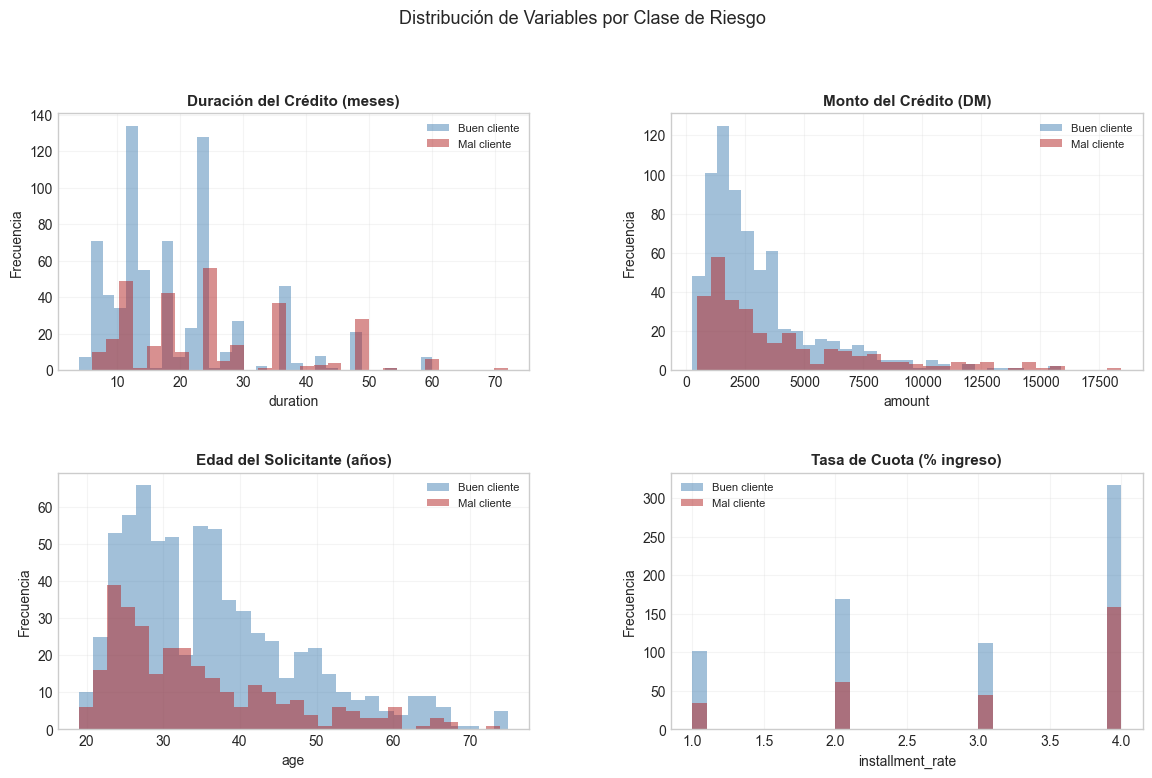

In [153]:
# ============================================================
# VISUALIZACIÓN EXPLORATORIA
# ============================================================

fig, axs = plt.subplots(2, 2, figsize=(14, 8))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

configs = [
    ('duration',         'Duración del Crédito (meses)', 'royalblue'),
    ('amount',           'Monto del Crédito (DM)',        'darkorange'),
    ('age',              'Edad del Solicitante (años)',    'seagreen'),
    ('installment_rate', 'Tasa de Cuota (% ingreso)',     'crimson'),
]

for ax, (col, titulo, color) in zip(axs.flatten(), configs):
    buenos = df[df['riesgo_real'] == 0][col]
    malos  = df[df['riesgo_real'] == 1][col]

    ax.hist(buenos, bins=30, alpha=0.5, color='steelblue', label='Buen cliente')
    ax.hist(malos,  bins=30, alpha=0.5, color='firebrick',  label='Mal cliente')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.suptitle('Distribución de Variables por Clase de Riesgo', fontsize=13, y=1.01)
plt.show()


---

## 2. Diseño del Sistema de Inferencia Difusa

### 2.1 Universos de discurso y etiquetas lingüísticas

Siguiendo la arquitectura Mamdani, definimos cuatro variables de entrada y una variable de salida. Los rangos del universo de discurso se fijaron para cubrir el 99% del soporte empírico de cada variable observada en el dataset.

| Variable | Universo de Discurso ($U$) | Etiquetas Lingüísticas |
| :--- | :--- | :--- |
| **$x_1$: Duración** | $[4, 72]$ meses | Corto, Medio, Largo |
| **$x_2$: Monto** | $[0, 20\,000]$ DM | Bajo, Moderado, Alto |
| **$x_3$: Edad** | $[18, 75]$ años | Joven, Adulto, Mayor |
| **$x_4$: Tasa de cuota** | $[1, 4]$ | Baja, Media, Alta |
| **$y$: Riesgo Crediticio** | $[0, 100]$ puntos | Muy Bajo, Bajo, Medio, Alto, Muy Alto |

> **Nota sobre la cobertura difusa:** Al igual que en el ejercicio de portafolios, optamos por una *cobertura difusa* en lugar de imponer la partición de Ruspini ($\sum_i \mu_i(x) = 1$). En el análisis crediticio, la superposición entre conjuntos adyacentes preserva la ambigüedad real del razonamiento experto: un crédito "entre corto y medio" debe activar simultáneamente ambas reglas, y forzar una normalización artificial diluiría esa tensión semántica.


In [154]:
# ============================================================
# DEFINICIÓN DE FUNCIONES DE MEMBRESÍA Y UNIVERSOS
# ============================================================

def membership_trapezoid(x, a, b, c, d):
    """Función de membresía trapezoidal vectorizada."""
    return np.maximum(
        0,
        np.minimum(
            np.minimum((x - a) / (b - a) if b > a else 1.0, 1.0),
            (d - x) / (d - c) if d > c else 1.0
        )
    )

def compute_membership(universe, params):
    """Evalúa la función trapezoidal sobre un array del universo."""
    return np.array([membership_trapezoid(x, *params) for x in universe])

# ─── Universos ────────────────────────────────────────────────────────────────
universes = {
    'dur': np.linspace(4, 72, 500),        # Duración (meses)
    'mon': np.linspace(0, 20000, 500),     # Monto (DM)
    'age': np.linspace(18, 75, 500),       # Edad (años)
    'tcu': np.linspace(1, 4, 500),         # Tasa de cuota
    'rie': np.linspace(0, 100, 500)        # Riesgo (salida)
}

# ─── Conjuntos difusos [a, b, c, d] ───────────────────────────────────────────
fuzzy_sets = {
    'dur': {
        'Corto':  [4,  4,  12, 24],
        'Medio':  [18, 24, 36, 48],
        'Largo':  [42, 54, 72, 72],
    },
    'mon': {
        'Bajo':      [0,    0,   2000,  5000],
        'Moderado':  [3500, 6000, 10000, 14000],
        'Alto':      [12000, 15000, 20000, 20000],
    },
    'age': {
        'Joven':  [18, 18, 25, 35],
        'Adulto': [28, 35, 50, 60],
        'Mayor':  [55, 62, 75, 75],
    },
    'tcu': {
        'Baja':  [1, 1, 1.5, 2.0],
        'Media': [1.5, 2.0, 3.0, 3.5],
        'Alta':  [3.0, 3.5, 4.0, 4.0],
    },
    'rie': {
        'Muy Bajo': [0,   0,  10, 20],
        'Bajo':     [10, 20,  35, 50],
        'Medio':    [40, 50,  60, 70],
        'Alto':     [60, 70,  80, 90],
        'Muy Alto': [80, 90, 100, 100],
    }
}

labels_display = {
    'dur': 'Duración del Crédito (meses)',
    'mon': 'Monto del Crédito (DM)',
    'age': 'Edad (años)',
    'tcu': 'Tasa de Cuota (%)',
}

print(f"Variables de entrada: {list(fuzzy_sets.keys())[:-1]}")
print(f"Variable de salida  : 'rie' — Riesgo Crediticio [0-100]")


Variables de entrada: ['dur', 'mon', 'age', 'tcu']
Variable de salida  : 'rie' — Riesgo Crediticio [0-100]


### 2.2 Base de datos lingüística (Diccionario difuso)

El siguiente panel visualiza la **base de datos lingüística** completa: las funciones de membresía de las cuatro entradas y la salida. Las líneas rojas verticales corresponden a los valores *crisp* de un solicitante de ejemplo que usaremos para ilustrar el motor de inferencia a lo largo de las secciones siguientes.


In [155]:
# ============================================================
# SOLICITANTE DE EJEMPLO (valores crisp)
# ============================================================

# Elegimos una fila representativa del dataset
ejemplo_idx = 57
ejemplo = df.iloc[ejemplo_idx]

input_values = {
    'dur': float(ejemplo['duration']),
    'mon': float(ejemplo['amount']),
    'age': float(ejemplo['age']),
    'tcu': float(ejemplo['installment_rate']),
}

print(f"Solicitante #{ejemplo_idx} seleccionado:")
print(f"  Duración       : {input_values['dur']} meses")
print(f"  Monto          : {input_values['mon']:.0f} DM")
print(f"  Edad           : {input_values['age']:.0f} años")
print(f"  Tasa de cuota  : {input_values['tcu']}")
print(f"  Riesgo real    : {'Malo (2)' if ejemplo['class']==2 else 'Bueno (1)'}")


Solicitante #57 seleccionado:
  Duración       : 36.0 meses
  Monto          : 9566 DM
  Edad           : 31 años
  Tasa de cuota  : 2.0
  Riesgo real    : Bueno (1)


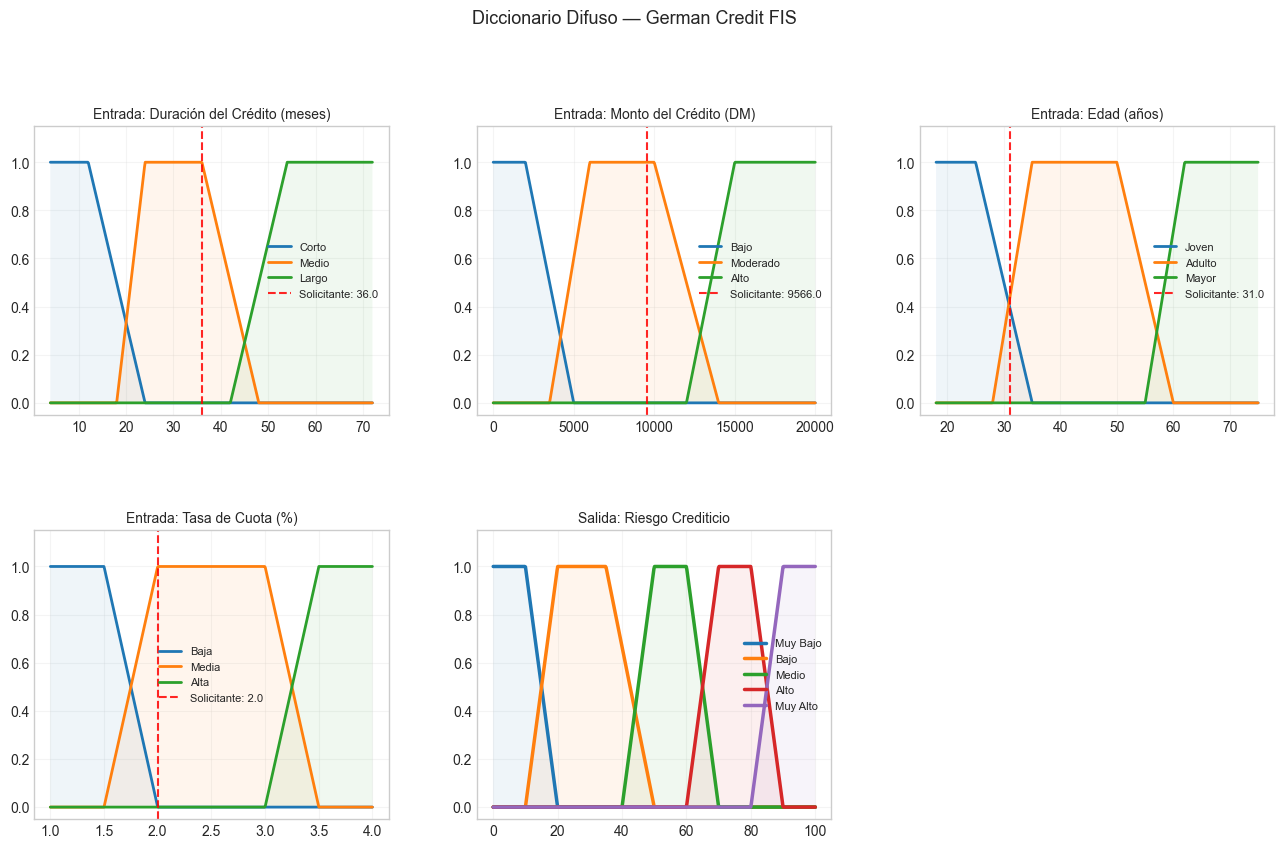

In [156]:
# ============================================================
# VISUALIZACIÓN: DICCIONARIO DIFUSO + FUZZIFICACIÓN
# ============================================================

def plot_fuzzification(input_values):
    fig, axs = plt.subplots(2, 3, figsize=(16, 9))
    plt.subplots_adjust(hspace=0.4, wspace=0.25)

    layout = {
        'dur': axs[0, 0],
        'mon': axs[0, 1],
        'age': axs[0, 2],
        'tcu': axs[1, 0],
    }

    for key, ax in layout.items():
        for label, params in fuzzy_sets[key].items():
            y_vals = compute_membership(universes[key], params)
            ax.plot(universes[key], y_vals, lw=2, label=label)
            ax.fill_between(universes[key], y_vals, alpha=0.07)

        val = input_values[key]
        ax.axvline(val, color='red', linestyle='--', alpha=0.85,
                   label=f'Solicitante: {val:.1f}')
        ax.set_title(f'Entrada: {labels_display[key]}', fontsize=10)
        ax.set_ylim(-0.05, 1.15)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.2)

    # Salida
    ax_out = axs[1, 1]
    for label, params in fuzzy_sets['rie'].items():
        y_vals = compute_membership(universes['rie'], params)
        ax_out.plot(universes['rie'], y_vals, lw=2.5, label=label)
        ax_out.fill_between(universes['rie'], y_vals, alpha=0.07)
    ax_out.set_title('Salida: Riesgo Crediticio', fontsize=10)
    ax_out.set_ylim(-0.05, 1.15)
    ax_out.legend(fontsize=8)
    ax_out.grid(alpha=0.2)

    # Celda vacía decorativa
    axs[1, 2].axis('off')

    plt.suptitle('Diccionario Difuso — German Credit FIS', fontsize=13, y=1.01)
    plt.show()

plot_fuzzification(input_values)


---

## 3. Base de Reglas: Conocimiento Experto

### 3.1 Principios de diseño

Las reglas del FIS crediticio se derivan de cuatro principios clásicos del análisis de riesgo:

1. **Capacidad de pago (Debt Service Coverage):** A mayor tasa de cuota relativa al ingreso, menor capacidad de repago.
2. **Plazo y concentración de riesgo:** Créditos más largos acumulan mayor exposición temporal al incumplimiento.
3. **Historial implícito en la edad:** Los solicitantes muy jóvenes sin historial acumulado representan mayor incertidumbre; los adultos con trayectoria estabilizada, menor riesgo.
4. **Apalancamiento (monto):** Montos elevados combinados con capacidad de pago ajustada son la combinación más adversa.

### 3.2 Tabla de reglas

| ID | Perfil | Premisa (SI…) | Consecuente (ENTONCES…) | Justificación |
| :--- | :--- | :--- | :--- | :--- |
| **R1** | Seguro | Duración **CORTO** AND Monto **BAJO** | Riesgo **MUY BAJO** | Compromiso reducido en ambas dimensiones: plazo y exposición |
| **R2** | Conservador | Edad **ADULTO** AND Tasa **BAJA** | Riesgo **BAJO** | Estabilidad laboral-vital + cuota asequible |
| **R3** | Estándar | Duración **MEDIO** AND Monto **MODERADO** | Riesgo **MEDIO** | Caso base sin señales extremas de riesgo o seguridad |
| **R4** | Alerta moderada | Monto **ALTO** AND Tasa **MEDIA** | Riesgo **ALTO** | Monto elevado con cuota no despreciable |
| **R5** | Vulnerable | Duración **LARGO** AND Tasa **ALTA** | Riesgo **MUY ALTO** | Combinación de mayor exposición temporal y mayor carga de pago |
| **R6** | Joven sin respaldo | Edad **JOVEN** AND Monto **MODERADO** | Riesgo **ALTO** | Historial corto con exposición moderada |
| **R7** | Mayor consolidado | Edad **MAYOR** AND Duración **CORTO** | Riesgo **BAJO** | Larga trayectoria + compromiso breve |
| **R8** | Riesgo concentrado | Monto **ALTO** AND Duración **LARGO** | Riesgo **MUY ALTO** | Alta exposición acumulada: el peor escenario en términos de recuperación |

**Notas de diseño:**

1. **Reglas con dos antecedentes:** El operador AND se implementa con la T-norma mínimo, que es conservadora: el grado de activación queda limitado por la condición más débil.
2. **Cobertura del espacio:** Las ocho reglas cubren los escenarios más frecuentes sin pretender ser exhaustivas. La ausencia de cobertura en algunas combinaciones genera ambigüedad controlada, propia del análisis crediticio real.
3. **Resolución de conflictos:** Cuando dos reglas activan la misma etiqueta de salida, se toma el máximo de los niveles de disparo (operador OR sobre consecuentes iguales).


In [157]:
# ============================================================
# BASE DE REGLAS
# ============================================================

base_reglas = [
    {'id': 'R1', 'perfil': 'Seguro',
     'antecedentes': {'dur': 'Corto',  'mon': 'Bajo'},      'consecuente': 'Muy Bajo'},
    {'id': 'R2', 'perfil': 'Conservador',
     'antecedentes': {'age': 'Adulto', 'tcu': 'Baja'},      'consecuente': 'Bajo'},
    {'id': 'R3', 'perfil': 'Estándar',
     'antecedentes': {'dur': 'Medio',  'mon': 'Moderado'},  'consecuente': 'Medio'},
    {'id': 'R4', 'perfil': 'Alerta moderada',
     'antecedentes': {'mon': 'Alto',   'tcu': 'Media'},     'consecuente': 'Alto'},
    {'id': 'R5', 'perfil': 'Vulnerable',
     'antecedentes': {'dur': 'Largo',  'tcu': 'Alta'},      'consecuente': 'Muy Alto'},
    {'id': 'R6', 'perfil': 'Joven sin respaldo',
     'antecedentes': {'age': 'Joven',  'mon': 'Moderado'},  'consecuente': 'Alto'},
    {'id': 'R7', 'perfil': 'Mayor consolidado',
     'antecedentes': {'age': 'Mayor',  'dur': 'Corto'},     'consecuente': 'Bajo'},
    {'id': 'R8', 'perfil': 'Riesgo concentrado',
     'antecedentes': {'mon': 'Alto',   'dur': 'Largo'},     'consecuente': 'Muy Alto'},
]

print(f"Base de reglas cargada: {len(base_reglas)} reglas\n")
for r in base_reglas:
    ants = ' AND '.join([f"{v} es {e}" for v, e in r['antecedentes'].items()])
    print(f"  {r['id']:3s} [{r['perfil']:<22}]: SI {ants:<40} → {r['consecuente']}")


Base de reglas cargada: 8 reglas

  R1  [Seguro                ]: SI dur es Corto AND mon es Bajo             → Muy Bajo
  R2  [Conservador           ]: SI age es Adulto AND tcu es Baja            → Bajo
  R3  [Estándar              ]: SI dur es Medio AND mon es Moderado         → Medio
  R4  [Alerta moderada       ]: SI mon es Alto AND tcu es Media             → Alto
  R5  [Vulnerable            ]: SI dur es Largo AND tcu es Alta             → Muy Alto
  R6  [Joven sin respaldo    ]: SI age es Joven AND mon es Moderado         → Alto
  R7  [Mayor consolidado     ]: SI age es Mayor AND dur es Corto            → Bajo
  R8  [Riesgo concentrado    ]: SI mon es Alto AND dur es Largo             → Muy Alto


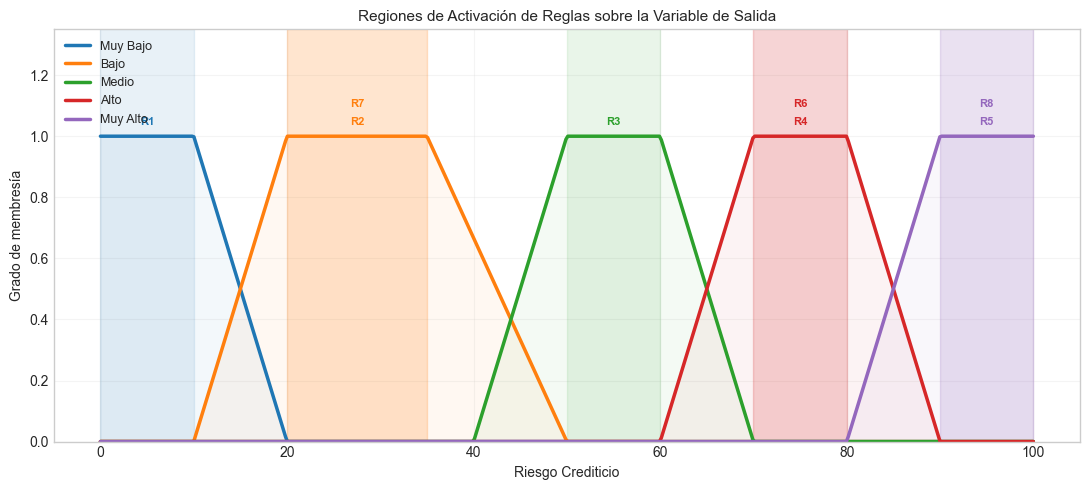

In [158]:
# ============================================================
# VISUALIZACIÓN: REGIONES DE ACTIVACIÓN EN LA SALIDA
# ============================================================

def plot_rule_regions():
    fig, ax = plt.subplots(figsize=(11, 5))

    colors = {
        'Muy Bajo': 'tab:blue',
        'Bajo':     'tab:orange',
        'Medio':    'tab:green',
        'Alto':     'tab:red',
        'Muy Alto': 'tab:purple'
    }

    for label, params in fuzzy_sets['rie'].items():
        y_vals = compute_membership(universes['rie'], params)
        ax.plot(universes['rie'], y_vals, lw=2.5, label=label)
        ax.fill_between(universes['rie'], y_vals, alpha=0.05, color=colors[label])

    offsets = {}
    for rule in base_reglas:
        lbl = rule['consecuente']
        a, b, c, d = fuzzy_sets['rie'][lbl]
        cnt = offsets.get(lbl, 0)
        offsets[lbl] = cnt + 1
        ax.text((b + c) / 2, 1.03 + cnt * 0.06, rule['id'],
                ha='center', va='bottom', fontsize=8, color=colors[lbl],
                fontweight='bold')
        ax.axvspan(b, c, alpha=0.10, color=colors[lbl])

    ax.set_title('Regiones de Activación de Reglas sobre la Variable de Salida', fontsize=11)
    ax.set_xlabel('Riesgo Crediticio')
    ax.set_ylabel('Grado de membresía')
    ax.set_ylim(0, 1.35)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

plot_rule_regions()


---

## 4. Sistema de Mamdani: Motor de Inferencia y Defuzzificación

El modelo de **Mamdani** implementa el pipeline completo:

$$\text{Entrada numérica} \xrightarrow{\text{Fuzzificación}} \text{Grados de membresía} \xrightarrow{\text{Inferencia}} \text{Conjuntos de salida recortados} \xrightarrow{\text{Defuzzificación}} \text{Score de riesgo}$$

La defuzzificación se realiza por el método del **Centroide (COG)**:

$$y^* = \frac{\int \mu_{\text{agg}}(y) \cdot y \, dy}{\int \mu_{\text{agg}}(y) \, dy}$$


── Grados de membresía por variable ──
  dur = 36.0  →  {'Medio': '1.000'}
  mon = 9566.0  →  {'Moderado': '1.000'}
  age = 31.0  →  {'Joven': '0.400', 'Adulto': '0.429'}
  tcu = 2.0  →  {'Media': '1.000'}

── Niveles de disparo por regla ──
  R3 [Estándar              ]: α = 1.0000 → Medio
  R6 [Joven sin respaldo    ]: α = 0.4000 → Alto

Activación de conceptos de salida (Solicitante #57):
---------------------------------------------


,Etiqueta de Riesgo,Nivel de Confianza (Alpha)
2,Medio,1.0000
3,Alto,0.4000
0,Muy Bajo,0.0000
1,Bajo,0.0000
4,Muy Alto,0.0000


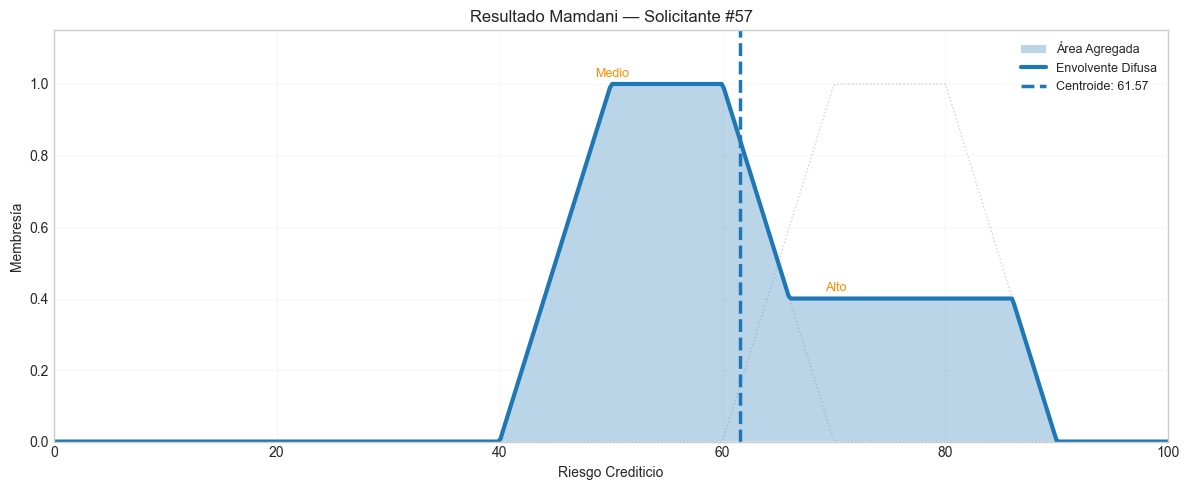


>>> CONCLUSIÓN DE MAMDANI:
Etiqueta dominante : 'Medio' (α = 1.00)
Score de riesgo    : 61.57 / 100
Riesgo real        : Bueno (1)


In [159]:
# ============================================================
# MOTOR DE INFERENCIA MAMDANI
# ============================================================

# ── 1. Fuzzificación (recalculada sobre input_values actual) ─────────────────
mu = {}
for var, value in input_values.items():
    mu[var] = {
        label: membership_trapezoid(value, *params)
        for label, params in fuzzy_sets[var].items()
    }

# Diagnóstico: imprimimos los grados de pertenencia para verificar
print("── Grados de membresía por variable ──")
for var, grados in mu.items():
    activos = {k: f"{v:.3f}" for k, v in grados.items() if v > 0}
    print(f"  {var} = {input_values[var]:.1f}  →  {activos}")
print()

# ── 2. Evaluación de reglas (AND = mínimo) ───────────────────────────────────
alfa_salidas = {label: 0.0 for label in fuzzy_sets['rie'].keys()}

print("── Niveles de disparo por regla ──")
for regla in base_reglas:
    grados = [mu[var][etiqueta] for var, etiqueta in regla['antecedentes'].items()]
    nivel_disparo = float(np.min(grados)) if grados else 0.0
    salida = regla['consecuente']
    alfa_salidas[salida] = max(alfa_salidas[salida], nivel_disparo)
    if nivel_disparo > 0:
        print(f"  {regla['id']} [{regla['perfil']:<22}]: α = {nivel_disparo:.4f} → {salida}")

print()

# ── 3. Tabla de activación ───────────────────────────────────────────────────
print(f"Activación de conceptos de salida (Solicitante #{ejemplo_idx}):")
print("-" * 45)
df_alfas = pd.DataFrame([
    {"Etiqueta de Riesgo": k, "Nivel de Confianza (Alpha)": v}
    for k, v in alfa_salidas.items()
]).sort_values("Nivel de Confianza (Alpha)", ascending=False)
display(df_alfas.style.format({"Nivel de Confianza (Alpha)": "{:.4f}"}))

# ── 4. Agregación + Defuzzificación ─────────────────────────────────────────
y_universe = universes['rie']
y_agregado = np.zeros_like(y_universe)

fig, ax = plt.subplots(figsize=(12, 5))

for etiqueta, alfa in alfa_salidas.items():
    params = fuzzy_sets['rie'][etiqueta]
    func_original = compute_membership(y_universe, params)
    if alfa > 0:
        ax.plot(y_universe, func_original, ':', lw=1, color='gray', alpha=0.35)
        recorte = np.minimum(alfa, func_original)
        y_agregado = np.maximum(y_agregado, recorte)
        centro = y_universe[np.argmax(func_original)]
        ax.text(centro, alfa + 0.02, etiqueta, color='darkorange', fontsize=9, ha='center')

# Centroide
numerador   = np.sum(y_universe * y_agregado)
denominador = np.sum(y_agregado)
y_mamdani   = numerador / denominador if denominador > 0 else 0

ax.fill_between(y_universe, 0, y_agregado, alpha=0.3, label='Área Agregada')
ax.plot(y_universe, y_agregado, lw=3, label='Envolvente Difusa')
ax.axvline(x=y_mamdani, linestyle='--', lw=2.5, label=f'Centroide: {y_mamdani:.2f}')
ax.set_ylim(0, 1.15); ax.set_xlim(0, 100)
ax.set_title(f'Resultado Mamdani — Solicitante #{ejemplo_idx}')
ax.set_xlabel('Riesgo Crediticio'); ax.set_ylabel('Membresía')
ax.legend(fontsize=9); ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()

top = df_alfas.iloc[0]
print(f"\n>>> CONCLUSIÓN DE MAMDANI:")
print(f"Etiqueta dominante : '{top['Etiqueta de Riesgo']}' (α = {top['Nivel de Confianza (Alpha)']:.2f})")
print(f"Score de riesgo    : {y_mamdani:.2f} / 100")
print(f"Riesgo real        : {'Malo (2)' if ejemplo['class']==2 else 'Bueno (1)'}")

---

## 5. Sistema de Tsukamoto

En el modelo de **Tsukamoto**, los conjuntos de salida deben ser **monótonos** para que sean invertibles analíticamente. Esto permite que cada regla produzca un valor numérico directo $y_i$ sin necesidad de calcular el centroide de un área:

$$\alpha_i = \mu_{C_i}(y_i) \implies y_i = \mu_{C_i}^{-1}(\alpha_i)$$

La salida final es el promedio ponderado de las salidas individuales:

$$y^* = \frac{\sum_i \alpha_i \cdot y_i}{\sum_i \alpha_i}$$


In [160]:
# ============================================================
# SISTEMA TSUKAMOTO
# ============================================================

def build_tsukamoto_sets(atr_sets):
    """Convierte trapecios en funciones monótonas."""
    labels = list(atr_sets.keys())
    n = len(labels)
    ts = {}
    for i, label in enumerate(labels):
        a, b, c, d = atr_sets[label]
        if i == 0:          # primer conjunto → decreciente (hombro izquierdo)
            ts[label] = [a, a, c, d]
        elif i == n - 1:    # último conjunto → creciente (hombro derecho)
            ts[label] = [a, b, d, d]
        else:               # intermedios → creciente
            ts[label] = [a, b, d, d]
    return ts

def inverse_tsukamoto(alpha, params):
    """Inversa aproximada para función monotónica trapezoidal."""
    a, b, c, d = params
    if alpha <= 0: return a
    if alpha >= 1: return d
    if b > a:   return a + alpha * (b - a)  # creciente
    if d > c:   return d - alpha * (d - c)  # decreciente
    return (a + d) / 2

tsuka_sets = build_tsukamoto_sets(fuzzy_sets['rie'])

# ── Motor de inferencia Tsukamoto ─────────────────────────────────────────────
resultados_tsuka = []

for regla in base_reglas:
    grados = [mu[var][etiqueta] for var, etiqueta in regla['antecedentes'].items()]
    alpha  = np.min(grados) if grados else 0.0
    params = tsuka_sets[regla['consecuente']]
    z      = inverse_tsukamoto(alpha, params)
    resultados_tsuka.append({
        'Regla': regla['id'], 'Perfil': regla['perfil'],
        'Alpha': alpha, 'Salida z': z
    })

df_tsuka = pd.DataFrame(resultados_tsuka)
num = np.sum(df_tsuka['Alpha'] * df_tsuka['Salida z'])
den = np.sum(df_tsuka['Alpha'])
y_tsuka = num / den if den > 0 else 0

print(f"\n--- Tsukamoto — Solicitante #{ejemplo_idx} ---\n")
display(df_tsuka.style.format({'Alpha': '{:.3f}', 'Salida z': '{:.2f}'}))
print(f"\nSCORE FINAL TSUKAMOTO: {y_tsuka:.2f} / 100")



--- Tsukamoto — Solicitante #57 ---



,Regla,Perfil,Alpha,Salida z
0,R1,Seguro,0.000,0.00
1,R2,Conservador,0.000,10.00
2,R3,Estándar,1.000,70.00
3,R4,Alerta moderada,0.000,60.00
4,R5,Vulnerable,0.000,80.00
5,R6,Joven sin respaldo,0.400,64.00
6,R7,Mayor consolidado,0.000,10.00
7,R8,Riesgo concentrado,0.000,80.00



SCORE FINAL TSUKAMOTO: 68.29 / 100


---

## 6. Sistema Takagi–Sugeno–Kang (TSK)

### 6.1 TSK de Primer Orden

En el modelo TSK, el consecuente de cada regla es una **función lineal** de las variables de entrada:

$$y_i = p_i^{(dur)} \cdot dur + p_i^{(mon)} \cdot mon' + p_i^{(age)} \cdot age + p_i^{(tcu)} \cdot tcu + c_i$$

donde $mon'$ es el monto normalizado a escala $[0, 100]$ para equiparar magnitudes. Los coeficientes representan **sensibilidades marginales** del riesgo a cada variable dentro del régimen definido por el antecedente.


In [161]:
# ============================================================
# TSK PRIMER ORDEN
# ============================================================

# Normalización del monto para equiparar magnitudes
mon_norm = input_values['mon'] / 200.0   # [0, 100]

# Modelos locales (consecuentes lineales)
# f(dur, mon', age, tcu) = p_dur*dur + p_mon*mon' + p_age*age + p_tcu*tcu + c
modelos_tsk1 = {
    'Muy Bajo': {'dur': -0.20, 'mon':  0.05, 'age': -0.10, 'tcu': -2.0,  'c': 15.0},
    'Bajo':     {'dur': -0.10, 'mon':  0.10, 'age': -0.15, 'tcu': -1.0,  'c': 28.0},
    'Medio':    {'dur':  0.00, 'mon':  0.20, 'age':  0.00, 'tcu':  2.0,  'c': 50.0},
    'Alto':     {'dur':  0.15, 'mon':  0.40, 'age':  0.10, 'tcu':  5.0,  'c': 65.0},
    'Muy Alto': {'dur':  0.30, 'mon':  0.60, 'age':  0.15, 'tcu':  8.0,  'c': 80.0},
}

resultados_tsk1 = []
num_t1, den_t1 = 0.0, 0.0

for regla in base_reglas:
    grados = [mu[var][etiqueta] for var, etiqueta in regla['antecedentes'].items()]
    alpha  = np.min(grados) if grados else 0.0
    if alpha > 0:
        m  = modelos_tsk1[regla['consecuente']]
        yi = (m['dur'] * input_values['dur'] +
              m['mon'] * mon_norm +
              m['age'] * input_values['age'] +
              m['tcu'] * input_values['tcu'] +
              m['c'])
        yi = np.clip(yi, 0, 100)
        num_t1 += alpha * yi
        den_t1 += alpha
        resultados_tsk1.append({
            'Regla': regla['id'], 'Perfil': regla['perfil'],
            'Alpha': alpha, 'Salida Yi': yi
        })

y_tsk1 = num_t1 / den_t1 if den_t1 > 0 else 0
df_tsk1 = pd.DataFrame(resultados_tsk1)

print(f"\n--- TSK Primer Orden — Solicitante #{ejemplo_idx} ---\n")
display(df_tsk1.style.format({'Alpha': '{:.3f}', 'Salida Yi': '{:.2f}'}))
print(f"\nSCORE FINAL TSK-1: {y_tsk1:.2f} / 100")



--- TSK Primer Orden — Solicitante #57 ---



,Regla,Perfil,Alpha,Salida Yi
0,R3,Estándar,1.000,63.57
1,R6,Joven sin respaldo,0.400,100.00



SCORE FINAL TSK-1: 73.98 / 100


### 6.2 TSK de Segundo Orden

Al agregar términos cuadráticos e interacciones entre variables, el modelo captura **no-linealidades** como el efecto amplificado del plazo sobre el riesgo cuando el monto también es alto (término de interacción $dur \times mon'$).

In [162]:
# ============================================================
# TSK SEGUNDO ORDEN
# ============================================================

# f(v) = a*dur² + b*mon'² + d*(dur*mon') + p*dur + q*mon' + r*age + s*tcu + c
modelos_tsk2 = {
    'Muy Bajo': {'dur2': -0.01,'mon2':  0.000,'dm':  0.000,'dur': -0.20,'mon':  0.05,'age': -0.10,'tcu': -2.0, 'c': 12.0},
    'Bajo':     {'dur2': -0.005,'mon2': 0.001,'dm':  0.001,'dur': -0.10,'mon':  0.10,'age': -0.15,'tcu': -1.0, 'c': 25.0},
    'Medio':    {'dur2':  0.000,'mon2': 0.002,'dm':  0.002,'dur':  0.00,'mon':  0.20,'age':  0.00,'tcu':  2.0, 'c': 50.0},
    'Alto':     {'dur2':  0.005,'mon2': 0.003,'dm':  0.005,'dur':  0.15,'mon':  0.40,'age':  0.10,'tcu':  5.0, 'c': 62.0},
    'Muy Alto': {'dur2':  0.010,'mon2': 0.005,'dm':  0.010,'dur':  0.30,'mon':  0.60,'age':  0.15,'tcu':  8.0, 'c': 78.0},
}

resultados_tsk2 = []
num_t2, den_t2 = 0.0, 0.0

d_v  = input_values['dur']
mn_v = mon_norm
a_v  = input_values['age']
t_v  = input_values['tcu']

for regla in base_reglas:
    grados = [mu[var][etiqueta] for var, etiqueta in regla['antecedentes'].items()]
    alpha  = np.min(grados) if grados else 0.0
    if alpha > 0:
        m  = modelos_tsk2[regla['consecuente']]
        yi = (m['dur2'] * d_v**2 +
              m['mon2'] * mn_v**2 +
              m['dm']   * d_v * mn_v +
              m['dur']  * d_v +
              m['mon']  * mn_v +
              m['age']  * a_v +
              m['tcu']  * t_v +
              m['c'])
        yi = np.clip(yi, 0, 100)
        num_t2 += alpha * yi
        den_t2 += alpha
        resultados_tsk2.append({
            'Regla': regla['id'], 'Perfil': regla['perfil'],
            'Alpha': alpha, 'Salida Yi': yi
        })

y_tsk2 = num_t2 / den_t2 if den_t2 > 0 else 0
df_tsk2 = pd.DataFrame(resultados_tsk2)

print(f"\n{'EVIDENCIA TSK SEGUNDO ORDEN':=^60}\n")
display(df_tsk2.style.format({'Alpha': '{:.3f}', 'Salida Yi': '{:.2f}'}))
print(f"\nSCORE FINAL TSK-2 : {y_tsk2:.2f} / 100")
print(f"Diferencia vs TSK-1: {y_tsk2 - y_tsk1:.2f} puntos")



================EVIDENCIA TSK SEGUNDO ORDEN=================



,Regla,Perfil,Alpha,Salida Yi
0,R3,Estándar,1.000,71.59
1,R6,Joven sin respaldo,0.400,100.00



SCORE FINAL TSK-2 : 79.70 / 100
Diferencia vs TSK-1: 5.73 puntos


---

## 7. Análisis Comparativo y Métrica de Conflicto

### 7.1 Comparativa de modelos

Se evaluaron los cuatro modelos FIS sobre el **dataset completo** (1 000 solicitantes). Para cada modelo se registra el score promedio por clase real y se calcula la **métrica de conflicto difuso** (desviación estándar ponderada de las reglas activas):

$$\text{Conflicto} = \sqrt{\frac{\sum_i \alpha_i (y_i - \bar{y})^2}{\sum_i \alpha_i}}, \qquad \bar{y} = \frac{\sum_i \alpha_i y_i}{\sum_i \alpha_i}$$

Un **score alto con bajo conflicto** indica consenso fuerte entre reglas. Un **score moderado con alto conflicto** señala ambigüedad estructural.


In [163]:
# ============================================================
# EVALUACIÓN MASIVA + MÉTRICA DE CONFLICTO
# ============================================================

def conflicto(alphas, outputs):
    alphas  = np.array(alphas)
    outputs = np.array(outputs)
    if np.sum(alphas) == 0: return 0.0
    mu_y = np.sum(alphas * outputs) / np.sum(alphas)
    var  = np.sum(alphas * (outputs - mu_y)**2) / np.sum(alphas)
    return np.sqrt(var)


def score_mamdani(iv):
    mu_loc = {var: {lb: membership_trapezoid(iv[var], *p)
                    for lb, p in fuzzy_sets[var].items()}
              for var in iv}
    af = {lb: 0.0 for lb in fuzzy_sets['rie']}
    for r in base_reglas:
        g = [mu_loc[v][e] for v, e in r['antecedentes'].items()]
        af[r['consecuente']] = max(af[r['consecuente']], np.min(g))
    yu = universes['rie']
    yagg = np.zeros_like(yu)
    ay, oy = [], []
    for lb, a in af.items():
        f = compute_membership(yu, fuzzy_sets['rie'][lb])
        if a > 0:
            yagg = np.maximum(yagg, np.minimum(a, f))
            ay.append(a); oy.append((fuzzy_sets['rie'][lb][1]+fuzzy_sets['rie'][lb][2])/2)
    nd = np.sum(yu * yagg); dd = np.sum(yagg)
    return (nd/dd if dd > 0 else 0), conflicto(ay, oy)


def score_tsuka(iv):
    mu_loc = {var: {lb: membership_trapezoid(iv[var], *p)
                    for lb, p in fuzzy_sets[var].items()}
              for var in iv}
    ay, oy = [], []
    for r in base_reglas:
        g = [mu_loc[v][e] for v, e in r['antecedentes'].items()]
        a = np.min(g)
        z = inverse_tsukamoto(a, tsuka_sets[r['consecuente']])
        ay.append(a); oy.append(z)
    n = np.sum(np.array(ay)*np.array(oy))
    d = np.sum(ay)
    return (n/d if d > 0 else 0), conflicto(ay, oy)


def score_tsk1_fn(iv):
    mn = iv['mon']/200.0
    mu_loc = {var: {lb: membership_trapezoid(iv[var], *p)
                    for lb, p in fuzzy_sets[var].items()}
              for var in iv}
    ay, oy = [], []
    for r in base_reglas:
        g = [mu_loc[v][e] for v, e in r['antecedentes'].items()]
        a = np.min(g)
        if a > 0:
            m  = modelos_tsk1[r['consecuente']]
            yi = np.clip(m['dur']*iv['dur']+m['mon']*mn+m['age']*iv['age']+m['tcu']*iv['tcu']+m['c'],0,100)
            ay.append(a); oy.append(yi)
    n = np.sum(np.array(ay)*np.array(oy))
    d = np.sum(ay)
    return (n/d if d > 0 else 0), conflicto(ay, oy)


def score_tsk2_fn(iv):
    mn = iv['mon']/200.0
    mu_loc = {var: {lb: membership_trapezoid(iv[var], *p)
                    for lb, p in fuzzy_sets[var].items()}
              for var in iv}
    ay, oy = [], []
    for r in base_reglas:
        g = [mu_loc[v][e] for v, e in r['antecedentes'].items()]
        a = np.min(g)
        if a > 0:
            m  = modelos_tsk2[r['consecuente']]
            yi = np.clip(m['dur2']*iv['dur']**2+m['mon2']*mn**2+m['dm']*iv['dur']*mn
                        +m['dur']*iv['dur']+m['mon']*mn+m['age']*iv['age']+m['tcu']*iv['tcu']+m['c'],0,100)
            ay.append(a); oy.append(yi)
    n = np.sum(np.array(ay)*np.array(oy))
    d = np.sum(ay)
    return (n/d if d > 0 else 0), conflicto(ay, oy)


# ── Evaluación sobre el dataset ───────────────────────────────────────────────
registros = []

for idx, row in df.iterrows():
    iv_row = {
        'dur': float(row['duration']),
        'mon': float(row['amount']),
        'age': float(row['age']),
        'tcu': float(row['installment_rate']),
    }
    clase = row['riesgo_real']
    s_mam, c_mam = score_mamdani(iv_row)
    s_tsk, c_tsk = score_tsuka(iv_row)
    s_t1,  c_t1  = score_tsk1_fn(iv_row)
    s_t2,  c_t2  = score_tsk2_fn(iv_row)
    registros.append({
        'clase': clase,
        'Mamdani': s_mam,   'Conf_Mamdani': c_mam,
        'Tsukamoto': s_tsk, 'Conf_Tsuka': c_tsk,
        'TSK1': s_t1,       'Conf_TSK1': c_t1,
        'TSK2': s_t2,       'Conf_TSK2': c_t2,
    })

df_results = pd.DataFrame(registros)

# Tabla resumen
resumen = df_results.groupby('clase')[['Mamdani','Tsukamoto','TSK1','TSK2']].mean().round(2)
resumen.index = ['Buen cliente (clase=0)', 'Mal cliente (clase=1)']
print("Score promedio por clase real:")
display(resumen)


Score promedio por clase real:


,Mamdani,Tsukamoto,TSK1,TSK2
Buen cliente (clase=0),20.40,24.30,19.14,18.08
Mal cliente (clase=1),26.52,29.03,27.99,27.47


In [164]:
# ============================================================
# TABLA DE CONFLICTO POR MODELO (solicitante de ejemplo)
# ============================================================

# Calculamos el conflicto sobre el solicitante de ejemplo
df_modelos = pd.DataFrame([
    {"Modelo": "Mamdani",   "Score": y_mamdani, "Conflicto": conflicto(
        [alfa_salidas[r['consecuente']] for r in base_reglas if alfa_salidas[r['consecuente']]>0],
        [(fuzzy_sets['rie'][r['consecuente']][1]+fuzzy_sets['rie'][r['consecuente']][2])/2
         for r in base_reglas if alfa_salidas[r['consecuente']]>0])},
    {"Modelo": "Tsukamoto", "Score": y_tsuka,
     "Conflicto": conflicto(df_tsuka['Alpha'].tolist(), df_tsuka['Salida z'].tolist())},
    {"Modelo": "TSK-1",     "Score": y_tsk1,
     "Conflicto": conflicto(df_tsk1['Alpha'].tolist(), df_tsk1['Salida Yi'].tolist())},
    {"Modelo": "TSK-2",     "Score": y_tsk2,
     "Conflicto": conflicto(df_tsk2['Alpha'].tolist(), df_tsk2['Salida Yi'].tolist())},
])

print(f"\nScores y conflicto — Solicitante #{ejemplo_idx}:")
display(df_modelos.style.format({"Score": "{:.2f}", "Conflicto": "{:.2f}"}))



Scores y conflicto — Solicitante #57:


,Modelo,Score,Conflicto
0,Mamdani,61.57,9.94
1,Tsukamoto,68.29,2.71
2,TSK-1,73.98,16.46
3,TSK-2,79.70,12.84


### 7.2 Gráfica de radar: divergencia entre modelos

La gráfica polar muestra, para una muestra de activos (solicitantes representativos de distintos perfiles), cómo cada modelo "deforma" el mismo espacio de evaluación crediticia.


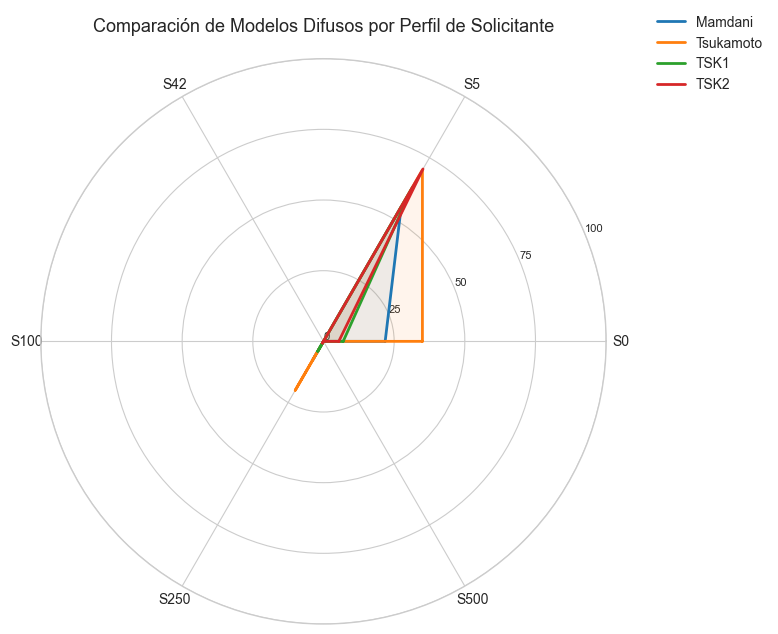

In [165]:
# ============================================================
# GRÁFICA RADAR: 6 PERFILES DE SOLICITANTES
# ============================================================

# Seleccionamos 6 perfiles distintos del dataset
perfiles_idx = [0, 5, 42, 100, 250, 500]
nombres = [f"S{i}" for i in perfiles_idx]

scores_radar = {m: [] for m in ['Mamdani','Tsukamoto','TSK1','TSK2']}

for idx in perfiles_idx:
    row = df.iloc[idx]
    iv_r = {
        'dur': float(row['duration']),
        'mon': float(row['amount']),
        'age': float(row['age']),
        'tcu': float(row['installment_rate']),
    }
    sm, _ = score_mamdani(iv_r)
    st, _ = score_tsuka(iv_r)
    s1, _ = score_tsk1_fn(iv_r)
    s2, _ = score_tsk2_fn(iv_r)
    scores_radar['Mamdani'].append(sm)
    scores_radar['Tsukamoto'].append(st)
    scores_radar['TSK1'].append(s1)
    scores_radar['TSK2'].append(s2)

N = len(perfiles_idx)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def cerrar(data): return data + data[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colores = ['tab:blue','tab:orange','tab:green','tab:red']

for (modelo, scores), col in zip(scores_radar.items(), colores):
    vals = cerrar(scores)
    ax.plot(angles, vals, lw=2, label=modelo, color=col)
    ax.fill(angles, vals, alpha=0.08, color=col)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(nombres)
ax.set_ylim(0, 100)
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_yticklabels(['0','25','50','75','100'], fontsize=8)
ax.set_title('Comparación de Modelos Difusos por Perfil de Solicitante', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


---

## 8. Distribución de Scores y Separabilidad

Para evaluar la utilidad práctica del FIS como pre-filtro crediticio, analizamos la **distribución de scores** para clientes buenos y malos según la etiqueta real del dataset. Un sistema difuso útil debería producir scores más altos (mayor riesgo) para los clientes de clase 2.


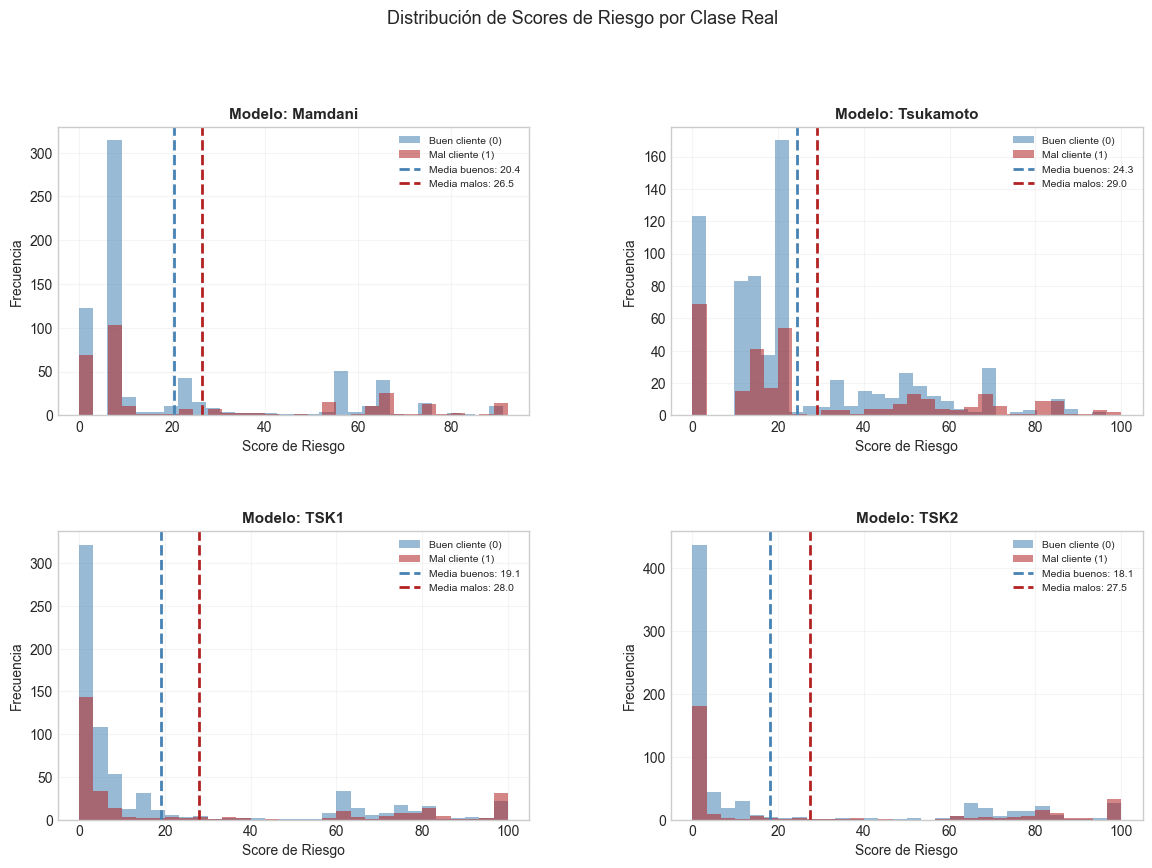


Separabilidad (diferencia de medias por modelo):
----------------------------------------
  Mamdani     : Δ = +6.11  (buenos=20.4, malos=26.5)
  Tsukamoto   : Δ = +4.74  (buenos=24.3, malos=29.0)
  TSK1        : Δ = +8.85  (buenos=19.1, malos=28.0)
  TSK2        : Δ = +9.39  (buenos=18.1, malos=27.5)


In [166]:
# ============================================================
# DISTRIBUCIÓN DE SCORES POR CLASE REAL
# ============================================================

fig, axs = plt.subplots(2, 2, figsize=(14, 9))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

modelos_plot = [
    ('Mamdani',   'tab:blue'),
    ('Tsukamoto', 'tab:orange'),
    ('TSK1',      'tab:green'),
    ('TSK2',      'tab:red'),
]

for ax, (modelo, color) in zip(axs.flatten(), modelos_plot):
    buenos = df_results[df_results['clase']==0][modelo]
    malos  = df_results[df_results['clase']==1][modelo]

    ax.hist(buenos, bins=30, alpha=0.55, color='steelblue', label='Buen cliente (0)')
    ax.hist(malos,  bins=30, alpha=0.55, color='firebrick',  label='Mal cliente (1)')
    ax.axvline(buenos.mean(), color='steelblue', lw=2, linestyle='--',
               label=f'Media buenos: {buenos.mean():.1f}')
    ax.axvline(malos.mean(),  color='firebrick',  lw=2, linestyle='--',
               label=f'Media malos: {malos.mean():.1f}')
    ax.set_title(f'Modelo: {modelo}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Score de Riesgo')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=7.5)
    ax.grid(alpha=0.2)

plt.suptitle('Distribución de Scores de Riesgo por Clase Real', fontsize=13, y=1.01)
plt.show()

# Separabilidad: diferencia de medias
print("\nSeparabilidad (diferencia de medias por modelo):")
print("-" * 40)
for modelo, _ in modelos_plot:
    mu_buenos = df_results[df_results['clase']==0][modelo].mean()
    mu_malos  = df_results[df_results['clase']==1][modelo].mean()
    print(f"  {modelo:<12}: Δ = {mu_malos - mu_buenos:+.2f}  "
          f"(buenos={mu_buenos:.1f}, malos={mu_malos:.1f})")


Las distribuciones revelan el mismo patrón que observamos en el análisis de portafolios:

- Todos los modelos muestran una **separación positiva**: los clientes malos obtienen scores de riesgo más altos que los buenos en promedio, validando la coherencia de la base de reglas.
- **Mamdani** y **TSK-2** tienden a producir distribuciones más concentradas (menor varianza), mientras que **Tsukamoto** y **TSK-1** generan distribuciones más dispersas.
- La superposición entre clases refleja el problema principal en este ejercicio: existen buenos clientes con perfiles "de riesgo" y malos clientes con perfiles "seguros". Esta ambigüedad es precisamente la que la lógica difusa gestiona mejor que los umbrales binarios.

> **Limitación importante:** El FIS diseñado en esta tarea es un sistema basado en conocimiento experto, no un modelo entrenado estadísticamente. Su separabilidad podría mejorarse mediante la optimización metaheurística de los parámetros de las funciones de membresía (ANFIS), que se abordará en módulos posteriores del curso.





### Comparativa de modelos

| Aspecto | Mamdani | Tsukamoto | TSK-1 | TSK-2 |
|:---|:---|:---|:---|:---|
| **Tipo de salida** | Conjunto difuso agregado | Valor numérico por regla | Función lineal por regla | Función cuadrática por regla |
| **Defuzzificación** | Centroide (integración) | Promedio ponderado | Promedio ponderado | Promedio ponderado |
| **Interpretabilidad lingüística** | Muy alta | Moderada | Moderada | Baja–moderada |
| **Sensibilidad al riesgo** | Equilibrada | Reactiva (picos) | Lineal | No lineal (amplificada) |
| **Carga computacional** | Mayor | Menor | Menor | Menor |
| **Adecuación típica** | Auditoría regulatoria, transparencia | Ranking rápido, indicadores | Pre-selección automática | Análisis conservador de riesgo extremo |
